# Prep notebook 4: Topography (DEM → per-edge elevation gain)

Downloads a Copernicus GLO-30 DEM (30 m resolution) for the destination
polygon, samples it at every network node, and computes per-edge
elevation gain / loss. The result is **asymmetric** by direction —
`u → v` gain equals `v → u` loss — which gives direction-dependent
travel times naturally for walk and bike.

Outputs: the three `.graphml` files in `data/prepared/` get updated
in-place with new attributes:

- **Per node**: `elevation` (m above sea level)
- **Per directed edge**: `elev_gain` (m climbed `u → v`),
  `elev_loss` (m descended `u → v`)

The aperta library function `topography.fetch_copernicus_dem` handles
AWS download, mosaic across 1° × 1° tiles, clip to the polygon, and
(optionally) reprojection to a metric CRS. For the default Bern + 40 km
scope that's 4 tiles covering 46–48° N × 6–8° E — cached locally on
first run.

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import rasterio
from shapely.geometry import Point

from aperta import geo_processing, network_processing, topography

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('../data/prepared')
CRS_METRIC = 'EPSG:2056'   # Swiss LV95

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Load inputs

In [2]:
walk_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'walk_graph.graphml')
bike_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'bike_graph.graphml')
car_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'car_graph.graphml')
print(f"Walk: {walk_graph.number_of_nodes():,} nodes / {walk_graph.number_of_edges():,} edges")
print(f"Bike: {bike_graph.number_of_nodes():,} nodes / {bike_graph.number_of_edges():,} edges")
print(f"Car:  {car_graph.number_of_nodes():,} nodes / {car_graph.number_of_edges():,} edges")

dest_polygon = gpd.read_file(PREPARED_DIR / 'dest_polygon.gpkg').geometry.iloc[0]

Walk: 204,450 nodes / 626,190 edges
Bike: 182,320 nodes / 507,250 edges
Car:  33,860 nodes / 90,839 edges


## 2. Download + mosaic + clip Copernicus DEM (30 m)

Per-tile 1° × 1° GeoTIFFs from AWS Open Data. The default Bern + 40 km
scope needs 4 tiles covering 46–48° N × 6–8° E; other scopes pull
whatever tiles intersect the dest polygon. Tiles + the clipped mosaic
are cached locally — re-running is fast on subsequent runs.

In [3]:
DEM_PATH = PREPARED_DIR / 'dem.tif'

topography.fetch_copernicus_dem(
    polygon=dest_polygon,
    out_path=DEM_PATH,
    polygon_crs=CRS_METRIC,
    target_crs=CRS_METRIC,
)

  Copernicus_DSM_COG_10_N46_00_E006_00_DEM ... 39 MB
  Copernicus_DSM_COG_10_N46_00_E007_00_DEM ... 42 MB
  Copernicus_DSM_COG_10_N46_00_E008_00_DEM ... 42 MB
  Copernicus_DSM_COG_10_N47_00_E006_00_DEM ... 43 MB
  Copernicus_DSM_COG_10_N47_00_E007_00_DEM ... 43 MB
  Copernicus_DSM_COG_10_N47_00_E008_00_DEM ... 42 MB
DEM saved to ../data/prepared/dem.tif: 3617 × 3941 pixels; elevation range 0–2439 m.


PosixPath('../data/prepared/dem.tif')

## 3. Per-node elevation + per-edge gain/loss

For each graph: sample DEM at every node, then walk every directed
edge and store `elev_gain` (the climb from `u` to `v`) and `elev_loss`
(the descent). The asymmetry across directions is what gives direction-
dependent travel times — a 100 m descent saves time compared to the
100 m climb in the reverse direction.

In [4]:
def add_elevation_features(graph: nx.MultiDiGraph, label: str) -> None:
    """Sample DEM at every node, compute per-edge gain/loss. Mutates `graph`."""
    print(f"\n--- {label} graph ---")

    node_ids = list(graph.nodes)
    nodes_gdf = gpd.GeoDataFrame(
        {'node_id': node_ids},
        geometry=[Point(graph.nodes[n]['x'], graph.nodes[n]['y'])
                  for n in node_ids],
        crs=CRS_METRIC,
    ).set_index('node_id')

    # Vectorised raster sample — single raster read + affine-transform
    # indexing. Orders of magnitude faster than OSMnx's
    # add_node_elevations_raster which does one GDAL RasterIO() per point.
    elevations = geo_processing.sample_raster_at_points(
        nodes_gdf, DEM_PATH, name='elevation',
    )
    nx.set_node_attributes(graph, elevations.to_dict(), name='elevation')
    print(f"  Elevations: range {elevations.min():.0f}–{elevations.max():.0f} m "
          f"(median {elevations.median():.0f}).")

    # Per directed edge: gain (climb from u to v) and loss (descent).
    # Symmetric across directions: u→v gain == v→u loss.
    for u, v, k, data in graph.edges(keys=True, data=True):
        dz = float(graph.nodes[v]['elevation']) - float(graph.nodes[u]['elevation'])
        data['elev_gain'] = max(0.0, dz)
        data['elev_loss'] = max(0.0, -dz)


add_elevation_features(walk_graph, 'walk')
add_elevation_features(bike_graph, 'bike')
add_elevation_features(car_graph, 'car')


--- walk graph ---
  Elevations: range 159–2373 m (median 591).

--- bike graph ---
  Elevations: range 159–2373 m (median 604).

--- car graph ---
  Elevations: range 247–1619 m (median 560).


## 4. Save updated networks

In [5]:
ox.save_graphml(walk_graph, PREPARED_DIR / 'walk_graph.graphml')
ox.save_graphml(bike_graph, PREPARED_DIR / 'bike_graph.graphml')
ox.save_graphml(car_graph, PREPARED_DIR / 'car_graph.graphml')
print("\nGraphs updated with `elevation` (per node) + `elev_gain` / `elev_loss` (per edge).")


Graphs updated with `elevation` (per node) + `elev_gain` / `elev_loss` (per edge).


## Appendix: eyeball check — node elevations on a map

Optional visual sanity check that elevations look right. (Default Bern
scope: city centre ~540 m above sea level, hills up to ~1200 m.) If the
DEM sampling silently broke (e.g. CRS mismatch), this would show a
flat / nonsensical surface regardless of location.

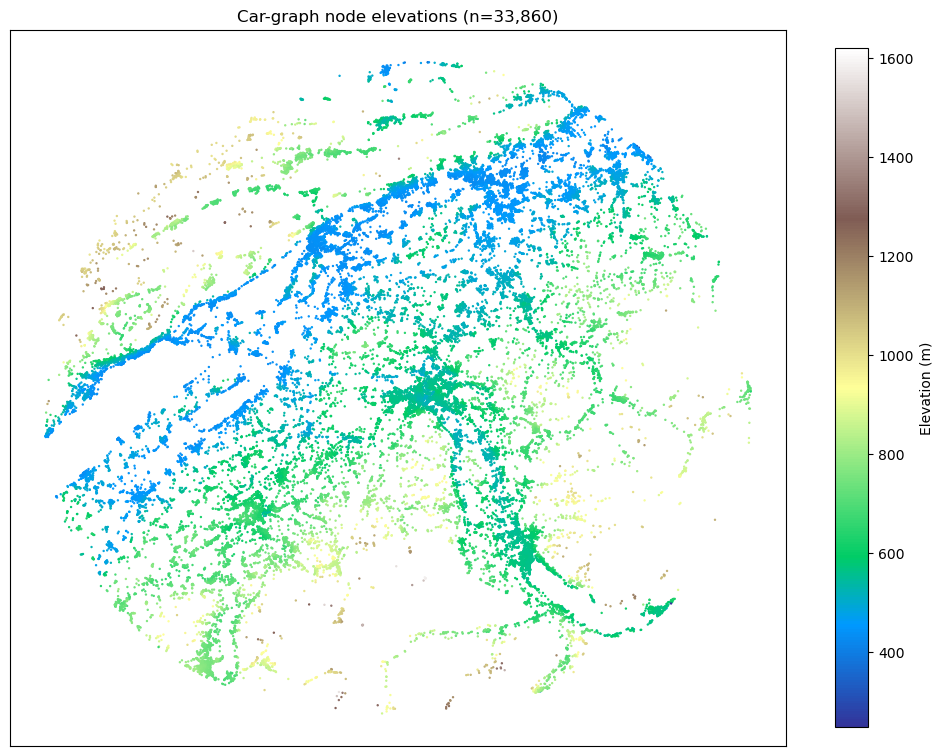

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
node_ids = list(car_graph.nodes)
xs = np.array([car_graph.nodes[n]['x'] for n in node_ids])
ys = np.array([car_graph.nodes[n]['y'] for n in node_ids])
zs = np.array([float(car_graph.nodes[n]['elevation']) for n in node_ids])
sc = ax.scatter(xs, ys, c=zs, s=0.5, cmap='terrain')
plt.colorbar(sc, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Car-graph node elevations (n={len(node_ids):,})')
plt.tight_layout()
plt.show()